<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [3]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [4]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [5]:
## Write your code here

# ================================
# DATA STRUCTURE OVERVIEW
# ================================

print("\n🔹 SHAPE OF DATASET")
print(df.shape)

print("\n🔹 COLUMN NAMES")
print(df.columns.tolist())

print("\n🔹 DATA TYPES")
print(df.dtypes)

print("\n🔹 BASIC INFO SUMMARY")
df.info()


🔹 SHAPE OF DATASET
(65437, 114)

🔹 COLUMN NAMES
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncH

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [6]:
## Write your code here

df.isna().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [7]:
df.isna().sum().sort_values(ascending=False)

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
MainBranch                        0
Age                               0
Employment                        0
Check                             0
ResponseId                        0
Length: 114, dtype: int64

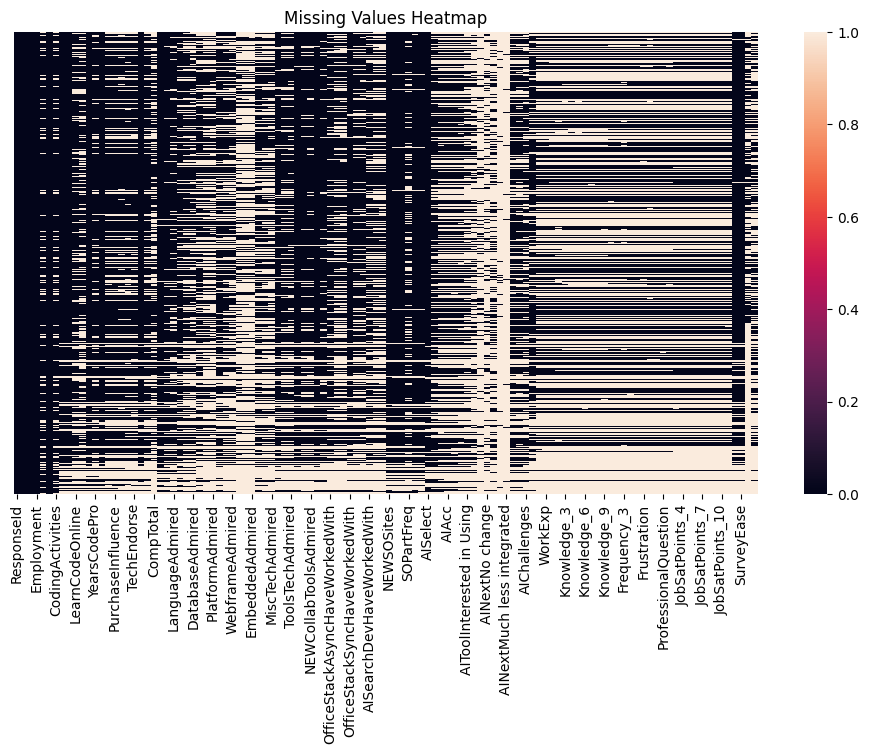

In [8]:
## Write your code here

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=True, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.show()

In [9]:
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False).head(20)

AINextMuch less integrated       98.245641
AINextLess integrated            96.401119
AINextNo change                  80.900714
AINextMuch more integrated       79.464217
EmbeddedAdmired                  74.428840
EmbeddedWantToWorkWith           73.103901
EmbeddedHaveWorkedWith           66.052845
ConvertedCompYearly              64.186928
AIToolNot interested in Using    62.690832
AINextMore integrated            62.669438
Knowledge_9                      57.768541
Frequency_3                      57.653927
Knowledge_8                      57.580574
ProfessionalTech                 57.571405
Knowledge_7                      57.550010
Knowledge_6                      57.418586
Knowledge_5                      57.394135
Knowledge_2                      57.178660
Knowledge_4                      57.164907
Knowledge_3                      57.065575
dtype: float64

In [10]:
cols_to_drop = missing_percent[missing_percent > 65].index
cols_to_drop

Index(['EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired',
       'AINextMuch more integrated', 'AINextNo change',
       'AINextLess integrated', 'AINextMuch less integrated'],
      dtype='str')

In [11]:
df_clean = df.drop(columns=cols_to_drop)
print("Shape of subset dataframe:", df_clean.shape)

Shape of subset dataframe: (65437, 107)

In [12]:
df_clean.isna().sum().sort_values(ascending=False)

ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
                                 ...  
Age                                  0
Employment                           0
MainBranch                           0
Check                                0
ResponseId                           0
Length: 107, dtype: int64

In [13]:
# Selecting more relevant columns for this specific lab

core_cols = [
    'ResponseId',
    'Age',
    'Country',
    'EdLevel',
    'Employment',
    'JobSat',
    'YearsCodePro',
    'RemoteWork',
    'LanguageHaveWorkedWith',
    'LanguageWantToWorkWith'
]

df_core = df_clean[core_cols].copy()
print("Shape of selected data:", df_core.shape)

Shape of selected data: (65437, 10)

In [14]:
df_core.isna().sum().sort_values(ascending=False)

JobSat                    36311
YearsCodePro              13827
RemoteWork                10631
LanguageWantToWorkWith     9685
Country                    6507
LanguageHaveWorkedWith     5692
EdLevel                    4653
ResponseId                    0
Age                           0
Employment                    0
dtype: int64

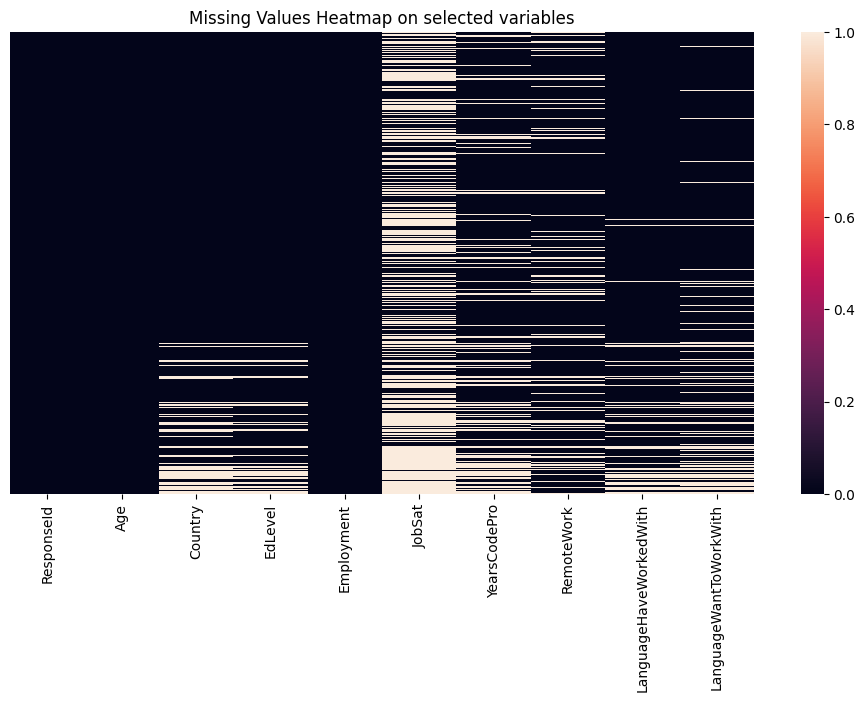

In [15]:
## Write your code here

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df_core.isna(), cbar=True, yticklabels=False)

plt.title("Missing Values Heatmap on selected variables")
plt.show()

Even after selecting onlythe relevant columns for this lab, droping all rows with missing seems incorrect. We will impute them instead

In [16]:
# Imputing numerical columns with median

num_cols = ['JobSat', 'YearsCodePro']

for col in num_cols:
    df_core[col] = pd.to_numeric(df_core[col], errors='coerce')
    df_core[col] = df_core[col].fillna(df_core[col].median())

In [17]:
# Imputation categorical columns with mode or more frequent

df_core['RemoteWork'] = df_core['RemoteWork'].fillna(
    df_core['RemoteWork'].mode()[0]
)

In [18]:
# Assigning "unknown" when appropriate

df_core['EdLevel'] = df_core['EdLevel'].fillna('Unknown')
df_core['Country'] = df_core['Country'].fillna('Unknown')

In [19]:
# Modifying the NaN or empty cell on two columns that contains semi-structured text lists (multiple languages in one cell)
# Later, we will probably have to use .str.split(";") & .explode() for frequency counts and language analysis, and this re-formatting would work best

text_cols = [
    'LanguageHaveWorkedWith',
    'LanguageWantToWorkWith'
]

for col in text_cols:
    df_core[col] = df_core[col].fillna('')

In [20]:
# We confirm that the subset data does not have missing values

missing_after = df_core.isna().sum().sort_values(ascending=False)
missing_after[missing_after > 0]

Series([], dtype: int64)

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [66]:
## Feature engineering for Employment

def simplify_employment(x):
    if pd.isna(x):
        return 'Other'
    
    first = x.split(';')[0]
    
    if first.startswith('Employed'):
        return 'Employed'
    elif first.startswith('Independent'):
        return 'Independent'
    elif first.startswith('Student'):
        return 'Student'
    elif 'but looking for work' in first:
        return 'Unemployed - Looking'
    elif 'and not looking for work' in first:
        return 'Unemployed - Not Looking'
    elif first.startswith('Retired'):
        return 'Retired'
    else:
        return 'Other'


df_core['Employment_Group'] = df_core['Employment'].apply(simplify_employment)

In [22]:
# Feature engineering for YearsCodePro

df_core['YearsCodePro_num'] = df_core['YearsCodePro'].replace(
    ['Less than 1 year', 'More than 50 years'],
    [0, 51]
)

df_core['YearsCodePro_num'] = pd.to_numeric(
    df_core['YearsCodePro_num'],
    errors='coerce'
)

In [23]:
# Also creating another column to categorize in broad groups years of experience in coding 

df_core['ExperienceLevel'] = pd.cut(
    df_core['YearsCodePro_num'],
    bins=[0, 5, 10, 20, 100],
    labels=['0-5', '5-10', '10-20', '20+']
)

In [24]:
# Changing format for JobSat

df_core['JobSat_num'] = pd.to_numeric(df_core['JobSat'], errors='coerce')

In [67]:
# Complete this task with value counts on the new columns created from Employment, JobSat, and YearsCodePro 

print("EMPLOYMENT GROUP DISTRIBUTION")
print(df_core['Employment_Group'].value_counts(dropna=False))

print("\nJOB SATISFACTION DISTRIBUTION")
print(df_core['JobSat_num'].value_counts(dropna=False).sort_index())

print("\nYEARS OF EXPERIENCE DISTRIBUTION")
print(df_core['YearsCodePro_num'].value_counts(dropna=False).sort_index())

print("\nYEARS OF EXPERIENCE CATEGORIES DISTRIBUTION")
print(df_core['ExperienceLevel'].value_counts(dropna=False))

EMPLOYMENT GROUP DISTRIBUTION
Employment_Group
Employed                    46436
Student                      8611
Independent                  5574
Unemployed - Looking         3040
Unemployed - Not Looking      705
Other                         546
Retired                       525
Name: count, dtype: int64

JOB SATISFACTION DISTRIBUTION
JobSat_num
0.0       311
1.0       276
2.0       772
3.0      1165
4.0      1130
5.0      1956
6.0      3751
7.0     42690
8.0      7509
9.0      3626
10.0     2251
Name: count, dtype: int64

YEARS OF EXPERIENCE DISTRIBUTION
YearsCodePro_num
1.0      2639
2.0      4168
3.0      4093
4.0      3215
5.0      3526
6.0      2843
7.0      2517
8.0     19282
9.0      1493
10.0     3251
11.0     1312
12.0     1777
13.0     1127
14.0     1082
15.0     1635
16.0      946
17.0      814
18.0      867
19.0      516
20.0     1549
21.0      380
22.0      492
23.0      448
24.0      632
25.0      998
26.0      426
27.0      380
28.0      342
29.0      196
30.0      

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


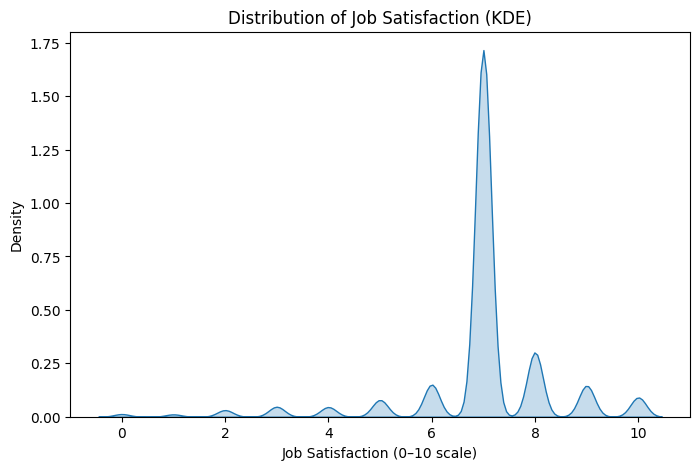

In [26]:
## Write your code here

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_core,
    x='JobSat_num',
    fill=True
)

plt.title('Distribution of Job Satisfaction (KDE)')
plt.xlabel('Job Satisfaction (0–10 scale)')
plt.ylabel('Density')

plt.show()

The distribution of job satisfaction is concentrated around higher values, with a clear peak at score 7, indicating that most respondents report moderately positive job satisfaction. Lower satisfaction levels (0–4) represent a much smaller proportion of the sample, suggesting that dissatisfaction is less common. Overall, the distribution is left-skewed, indicating generally positive job satisfaction across respondents.

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [27]:
## Clean and explode languages on both columns

have = (
    df_core['LanguageHaveWorkedWith']
    .fillna('')
    .str.split(';')
    .explode()
    .value_counts()
)

want = (
    df_core['LanguageWantToWorkWith']
    .fillna('')
    .str.split(';')
    .explode()
    .value_counts()
)

In [28]:
# Combine into one dataframe

lang_compare = pd.DataFrame({
    'Have_Worked': have,
    'Want_To_Work': want
}).fillna(0)

lang_compare = lang_compare.sort_values('Have_Worked', ascending=False)

In [29]:
lang_compare.head(10)

,Have_Worked,Want_To_Work
JavaScript,37492,23774
HTML/CSS,31816,20721
Python,30719,25047
SQL,30682,22400
TypeScript,23150,20239
Bash/Shell (all shells),20412,13744
Java,18239,10668
C#,16318,12921
C++,13827,10873
C,12184,8275


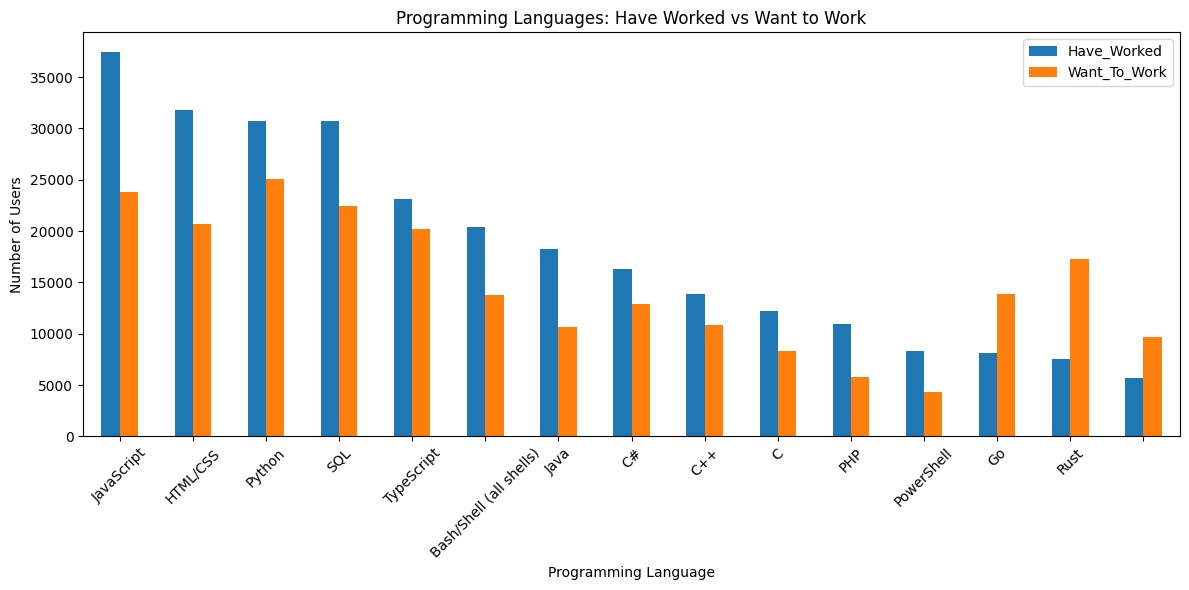

In [30]:
# Grouped barchart

import matplotlib.pyplot as plt

top_n = 15
lang_top = lang_compare.head(top_n)

lang_top.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Programming Languages: Have Worked vs Want to Work')
plt.xlabel('Programming Language')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [41]:
!pip install country_converter

In [42]:
import logging
import country_converter as coco

# Get the logger used internally by country_converter
coco_logger = logging.getLogger("country_converter")

# Silence warnings (only critical errors will appear)
coco_logger.setLevel(logging.CRITICAL)

# Optional: prevent propagation to root logger
coco_logger.propagate = False

In [43]:
# Creating a new column with continents based on the country column

df_core['Continent'] = coco.convert(
    names=df_core['Country'],
    to='continent',
    not_found=None
)

In [44]:
df_core['Continent'].value_counts()

Continent
Europe     28579
America    16320
Asia       10486
Unknown     6507
Africa      1837
Oceania     1665
Nomadic       43
Name: count, dtype: int64

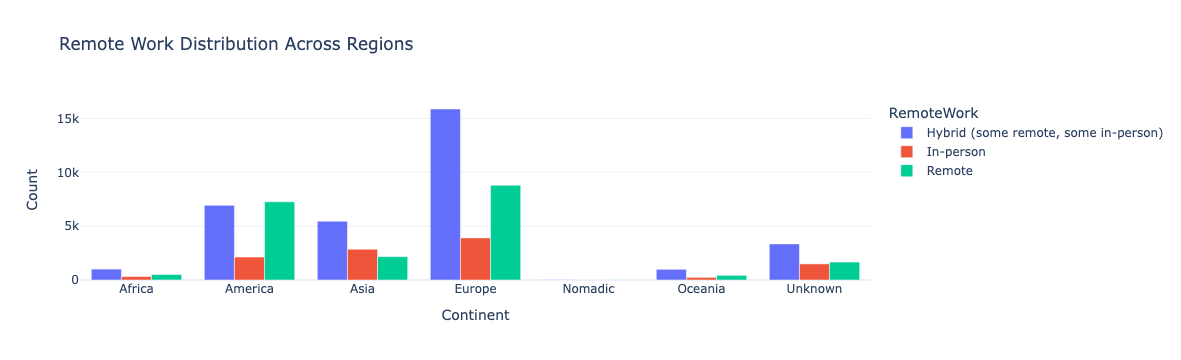

In [46]:
# Visializing the distribution of RemoteWork on regions or continents

import plotly.express as px

# Group only filtered data
rw_counts = (
    df_core
    .groupby(['Continent', 'RemoteWork'])
    .size()
    .reset_index(name='Count')
)

# Plot
fig = px.bar(
    rw_counts,
    x='Continent',
    y='Count',
    color='RemoteWork',
    barmode='group',
    title='Remote Work Distribution Across Regions',
    template='plotly_white'
)

fig.update_layout(xaxis_tickangle=0)
fig.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [51]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 138.2 MB/s eta 0:00:00


In [58]:
## Write your code here

import scipy

df_corr = df_core[['JobSat_num', 'YearsCodePro_num']].dropna()

pearson = df_corr['JobSat_num'].corr(df_corr['YearsCodePro_num'], method='pearson')
spearman = df_corr['JobSat_num'].corr(df_corr['YearsCodePro_num'], method='spearman')

print(f"Pearson: {pearson:.3f}")
print(f"Spearman: {spearman:.3f}")


Pearson: 0.071
Spearman: 0.084

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [68]:
## Tabulate the categories in both columns

print("Counts Employment_Group:", df_core['Employment_Group'].value_counts())
print()
print("Counts Education Level:", df_core['EdLevel'].value_counts())

Counts Employment_Group: Employment_Group
Employed                    46436
Student                      8611
Independent                  5574
Unemployed - Looking         3040
Unemployed - Not Looking      705
Other                         546
Retired                       525
Name: count, dtype: int64

Counts Education Level: EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Unknown                                                                                4653
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementar

In [69]:
# Creating a new column with broader categories for educational level [a similar code was used before for employment  variable]

def simplify_education(x):
    if pd.isna(x):
        return 'Other'
    
    if 'Primary' in x or 'Secondary' in x:
        return 'High school or lower'
    
    elif 'Some college' in x or 'without earning a degree' in x:
        return 'Some university (no degree)'
    
    elif 'Associate' in x:
        return 'Associate degree'
    
    elif 'Bachelor' in x:
        return 'Bachelor degree'
    
    elif 'Master' in x:
        return 'Master degree'
    
    elif 'Professional degree' in x or 'Ph.D' in x or 'doctoral' in x.lower():
        return 'Doctoral / Professional'
    
    else:
        return 'Other'


df_core['Education_Group'] = df_core['EdLevel'].apply(simplify_education)

In [70]:
print("Counts Education Group Level:", df_core['Education_Group'].value_counts())

Counts Education Group Level: Education_Group
Bachelor degree                24942
Master degree                  15557
Some university (no degree)     7651
High school or lower            6939
Other                           5585
Doctoral / Professional         2970
Associate degree                1793
Name: count, dtype: int64

In [71]:
# Cross-tab (Education vs Employment)

edu_emp = pd.crosstab(
    df_core['Education_Group'],
    df_core['Employment_Group']
)

edu_emp

Employment_Group,Employed,Independent,Other,Retired,Student,Unemployed - Looking,Unemployed - Not Looking
Education_Group,,,,,,,
Associate degree,1299,166,9,18,191,100,10
Bachelor degree,19538,1811,96,158,1959,1225,155
Doctoral / Professional,2397,286,29,96,63,82,17
High school or lower,2199,517,143,24,3448,351,257
Master degree,12812,1503,53,117,501,499,72
Other,3554,436,165,35,966,333,96
Some university (no degree),4637,855,51,77,1483,450,98


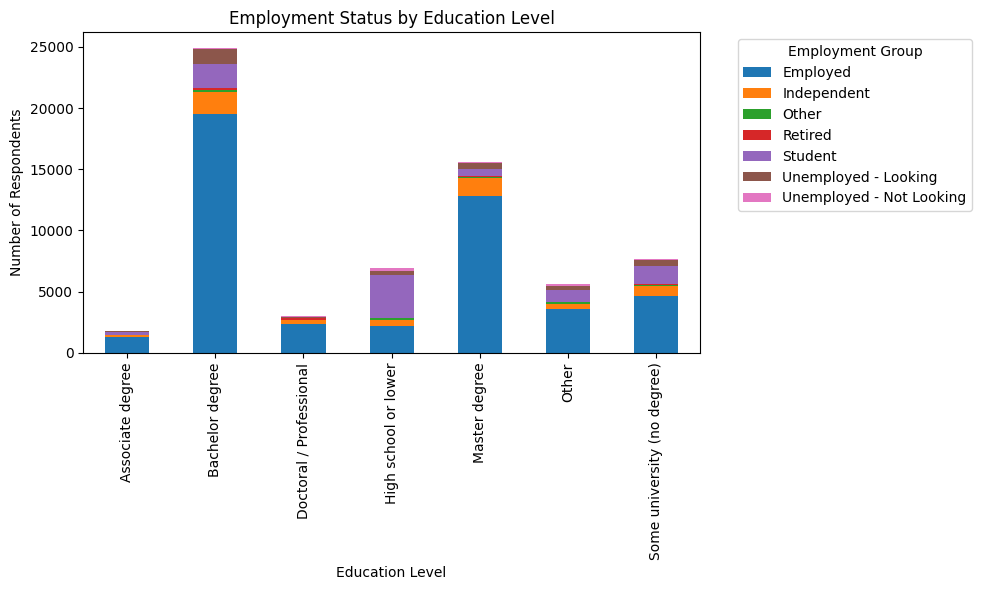

In [72]:
# Visualizing with stacked bar plot


import matplotlib.pyplot as plt

# Stacked bar plot
edu_emp.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')

plt.legend(
    title='Employment Group',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

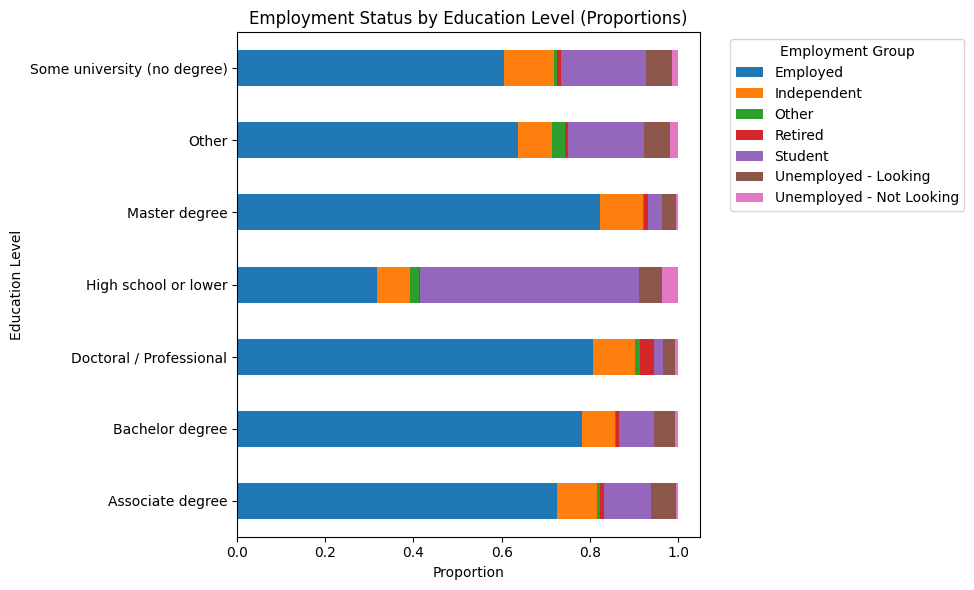

In [75]:
edu_emp_prop = pd.crosstab(
    df_core['Education_Group'],
    df_core['Employment_Group'],
    normalize='index'
)

edu_emp_prop.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6)
)

plt.title('Employment Status by Education Level (Proportions)')
plt.xlabel('Proportion')
plt.ylabel('Education Level')

plt.legend(
    title='Employment Group',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [76]:
## Write your code here

# Save cleaned dataset as CSV

df_core.to_csv('clean_survey_EDA.csv', index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
